In [0]:
spark.sql("USE CATALOG mvp")
spark.sql("USE SCHEMA gold") 

DataFrame[]

In [0]:
%sql
SELECT *
FROM ind_prod_ilha_completa
LIMIT 10

NomeBase,NomeIlha,IdBase,Data,IdIlha,TempoProducaoReal,TempoProducaoPlan,QuantProducaoReal,QuantProducaoPlan,QuantProducaoRuim,QuantProducaoBoa
Base 1,Ilha 1,1,2025-11-01,50121,26513,54000,383117,574675,0,65
Base 1,Ilha 9,1,2025-11-01,501213,9483,54000,122347,183521,10,13
Base 1,Ilha 8,1,2025-11-01,501219,6319,54000,82999,124498,0,16
Base 1,Ilha 2,1,2025-11-01,50122,22583,54000,340031,510047,0,58
Base 1,Ilha 3,1,2025-11-01,50123,25494,54000,444020,666030,0,91
Base 1,Ilha 4,1,2025-11-01,50124,25462,54000,441043,661565,0,91
Base 1,Ilha 5,1,2025-11-01,50125,29855,54000,463091,694637,0,96
Base 1,Ilha 6,1,2025-11-01,50126,23201,54000,392061,588092,0,78
Base 1,SKID_Alc1,1,2025-11-01,50127,21000,54000,480832,721248,8,0
Base 1,SKID_Alc2,1,2025-11-01,50128,27300,54000,300375,450562,5,0


In [0]:
%sql
-- Qual foi o indicador de disponibilidade, performance e qualidade das ilhas do terminal 5012 no mês de janeiro de 2025
SELECT 
  ind.NomeBase,
  ind.NomeIlha,
  ROUND(
    SUM(CAST(ind.TempoProducaoReal AS DOUBLE) / CAST(ind.TempoProducaoPlan AS DOUBLE))
    ,2
  ) AS indicador_disponibilidade,
  ROUND(SUM(CAST(ind.QuantProducaoReal AS DOUBLE) / CAST(ind.QuantProducaoPlan AS DOUBLE)),2) AS indicador_performance,
  ROUND(
    SUM(
      CAST(ind.QuantProducaoBoa AS DOUBLE) / 
      ( CAST(ind.QuantProducaoRuim AS DOUBLE) + CAST(ind.QuantProducaoBoa As DOUBLE) )
    ),2
  ) AS indicador_qualidade,
  ROUND(
    (indicador_disponibilidade * indicador_performance * indicador_qualidade)
    ,2
    ) AS indicador_oee
FROM ind_prod_ilha_completa AS ind
WHERE ind.IdBase = 1
  AND CAST(ind.Data As DATE) BETWEEN CAST('2025-11-01' As DATE) AND CAST('2025-11-30' As DATE)
GROUP BY ind.NomeBase, ind.NomeIlha

NomeBase,NomeIlha,indicador_disponibilidade,indicador_performance,indicador_qualidade,indicador_oee
Base 1,Ilha 1,14.64,16.67,24.76,6042.65
Base 1,Ilha 9,2.67,16.67,23.58,1049.52
Base 1,Ilha 8,3.37,16.67,24.83,1394.9
Base 1,Ilha 2,13.64,16.67,24.89,5659.46
Base 1,Ilha 3,15.06,16.67,24.95,6263.7
Base 1,Ilha 4,15.71,16.67,24.95,6534.05
Base 1,Ilha 5,15.85,16.67,24.99,6602.85
Base 1,Ilha 6,11.62,16.67,24.92,4827.14
Base 1,SKID_Alc1,4.89,8.0,5.57,217.9
Base 1,SKID_Alc2,2.59,7.33,6.81,129.29


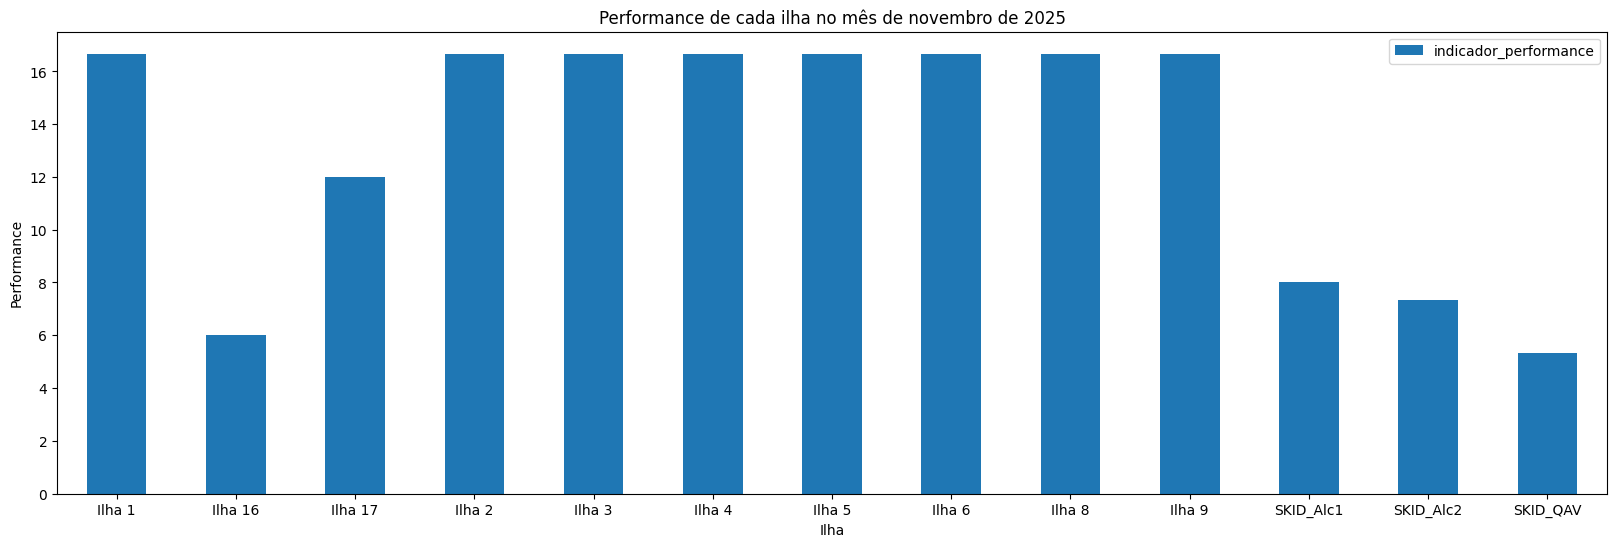

In [0]:
# Usar a bilioteca pandas pra gerar um gráfico de barras contendo a performance de cada ilha no mês de novembro de 2025
import pandas as pd
import matplotlib.pyplot as plt
df = spark.sql("SELECT NomeIlha, ROUND(SUM(CAST(ind.QuantProducaoReal AS DOUBLE) / CAST(ind.QuantProducaoPlan AS DOUBLE)),2) AS indicador_performance FROM ind_prod_ilha_completa AS ind WHERE Data >= '2025-11-01' AND Data < '2025-12-01' AND NomeBase='Base 1' GROUP BY NomeIlha ORDER BY NomeIlha")
df = df.toPandas()
df.plot.bar(x='NomeIlha', y='indicador_performance', rot=0, figsize=(20, 6))
plt.title('Performance de cada ilha no mês de novembro de 2025')
plt.xlabel('Ilha')
plt.ylabel('Performance')
plt.show()
